### Import Library

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import skfuzzy as fuzz
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Simulation

In [11]:
# Load results of pca from Kimia dataset
df = pd.read_csv("kimia_pca.csv")
X = df.drop('Class', axis=1).values
y = df['Class'].values

In [12]:
# Split 7:1:2
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=209, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)

# Perform KNN on TRAINING data
kmeans = KNeighborsClassifier(n_neighbors=3)
kmeans.fit(X_train,y_train)

cluster_train = kmeans.predict(X_train)
cluster_test = kmeans.predict(X_test)
cluster_val = kmeans.predict(X_val)

In [13]:
# mapping cluster → class
mapping = {}

for i in range(2):
    idx = np.where(cluster_train == i)
    majority_label = np.bincount(y_train[idx]).argmax()
    mapping[i] = majority_label

print("Cluster mapping:", mapping)

Cluster mapping: {0: np.int64(0), 1: np.int64(1)}


In [14]:
y_pred = np.vectorize(mapping.get)(cluster_test)
y_pred_val = np.vectorize(mapping.get)(cluster_val)


In [15]:
acc = accuracy_score(y_test, y_pred)
print("KNN Test Accuracy:", acc)

acc_val = accuracy_score(y_val, y_pred_val)
print("KNN Validation Accuracy:", acc_val)


KNN Test Accuracy: 0.7792792792792793
KNN Validation Accuracy: 0.7657657657657657


In [16]:
prob_test = kmeans.predict_proba(X_test)[:, 1]
prob_val = kmeans.predict_proba(X_val)[:, 1]

In [17]:
auc_score = roc_auc_score(
    y_test,
    prob_test
)
val_auc_score = roc_auc_score(
    y_val,
    prob_val
)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"ROC-AUC Score (Validation): {val_auc_score:.4f}")

ROC-AUC Score: 0.8646
ROC-AUC Score (Validation): 0.8771


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, prob_test)
roc_auc = roc_auc_score(y_test, prob_test)

print("KNN ROC-AUC:", roc_auc)

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, prob_val)
roc_auc_val = roc_auc_score(y_val, prob_val)

print("KNN Validation ROC-AUC:", roc_auc_val)


KNN ROC-AUC: 0.8646213781348917
KNN Validation ROC-AUC: 0.8771103896103896


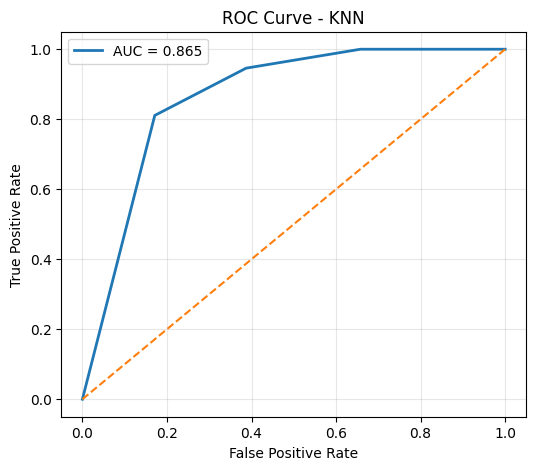

In [19]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

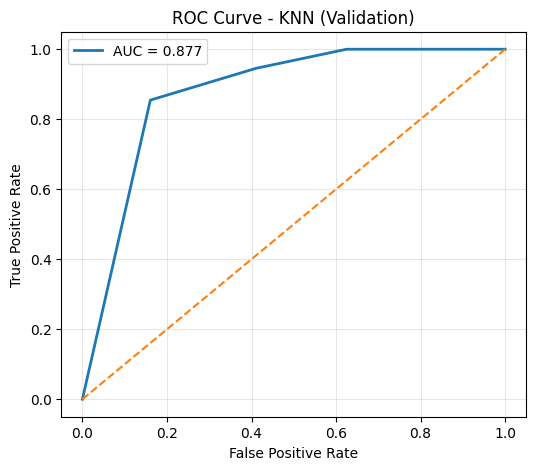

In [20]:
plt.figure(figsize=(6,5))

plt.plot(fpr_val, tpr_val, label=f"AUC = {roc_auc_val:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN (Validation)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

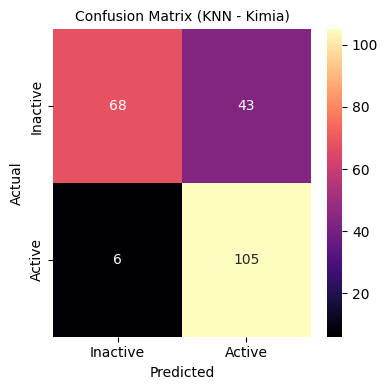

In [28]:
class_names = ['Inactive', 'Active']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
                xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.title(f'Confusion Matrix (KNN - Kimia)',
              fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
print("Classification Report (KNN)")
print(classification_report(y_test, y_pred, digits=4))

Classification Report (KNN)
              precision    recall  f1-score   support

           0     0.9189    0.6126    0.7351       111
           1     0.7095    0.9459    0.8108       111

    accuracy                         0.7793       222
   macro avg     0.8142    0.7793    0.7730       222
weighted avg     0.8142    0.7793    0.7730       222



In [24]:
print("Classification Report - KNN (Validation)")
print(classification_report(y_val, y_pred_val, digits=4))

Classification Report - KNN (Validation)
              precision    recall  f1-score   support

           0     0.9167    0.5893    0.7174        56
           1     0.6933    0.9455    0.8000        55

    accuracy                         0.7658       111
   macro avg     0.8050    0.7674    0.7587       111
weighted avg     0.8060    0.7658    0.7583       111



In [25]:
hasil = pd.DataFrame(X_test[:,:2])
hasil.columns = ['PC1', 'PC2']
hasil = pd.concat([hasil, pd.Series(y_pred, name='Class')], axis=1)

hasil_centroids = hasil.groupby('Class')[['PC1', 'PC2']].mean()

# Display centroids
print(hasil_centroids)

            PC1       PC2
Class                    
0      0.092186 -0.267837
1     -0.143578  0.121934


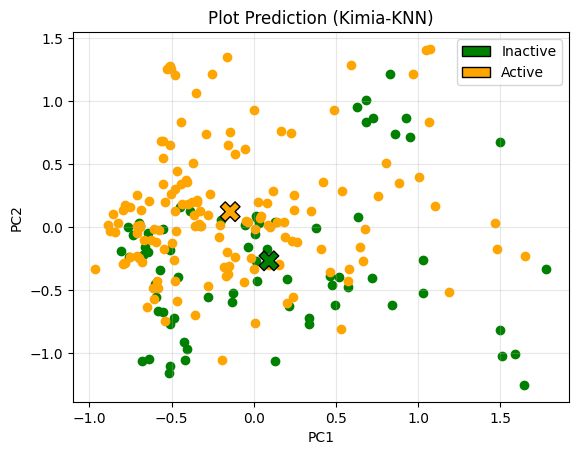

In [26]:
class_names = ['Inactive', 'Active']
colors = ['green', 'orange']
marker_colors = {1: 'green', 2: 'orange'}


for i, class_id in enumerate(sorted(np.unique(hasil["Class"]))):
    mask = hasil["Class"] == class_id
    plt.scatter(hasil[mask]['PC1'], hasil[mask]['PC2'], c=colors[i],
                label=f'{class_names[i]}')

# Plot centroids
plt.scatter(hasil_centroids['PC1'], hasil_centroids['PC2'], 
            c=[marker_colors[1], marker_colors[2]], marker='X', s=200, 
            edgecolors='black', linewidth=1)

# Add custom legend for centroids
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=marker_colors[1], edgecolor='black', label='Inactive'),
                   Patch(facecolor=marker_colors[2], edgecolor='black', label='Active')]
plt.legend(handles=legend_elements)

plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.title('Plot Prediction (Kimia-KNN)')
plt.grid(True, alpha=0.3)
plt.show()